In [2]:
import numpy as np
from scipy import integrate as intg
import matplotlib.pyplot as plt
import itertools
import mysindy

In [3]:
import pynumdiff as nd # some submodules requrie cvxpy or tqdm

In [4]:
noise_std = 0.1
rng = np.random.default_rng()
noise_generator = lambda size: rng.normal(scale=noise_std, size=size)

In [5]:
def lorenz(xyz, *, sigma=10, rho=28, beta=8 / 3):
    """
    Parameters
    ----------
    xyz : array-like, shape (3,)
        Coordinates.
    sigma : float
        Prandtl number.
    rho : float
        Rayleigh number.
    beta : float
        Parameter related to fluid dimensions.

    Returns
    -------
    xyz_dot : array, shape (3,)
        Time derivative of x.
    """
    x, y, z = xyz
    x_dot = sigma * (y - x)
    y_dot = x * (rho - z) - y
    z_dot = x * y - beta * z
    return np.array([x_dot, y_dot, z_dot])

In [6]:
def integrate_ode(dx_dt, x_0, t_arr, *, args=None, **options):
    """
    Parameters
    ----------
    dx_dt : function
        Time derivative of x, with call signature f(t, x, *args).
    x_0 : array-like, shape (n,)
        Initial value of x.
    t_arr : array-like, shape (n_points,)
        Array of points at which x is evaluated.
    args : tuple, optional
        Extra arguments for dx_dt, by default None.
    **options
        Options passed to scipy.integrate.solve_ivp().

    Returns
    -------
    x : ndarray, shape (n, n_points)
        x evaluated at points specified by t_arr.
    """    
    t_span = t_arr[[0, -1]]
    solution = intg.solve_ivp(dx_dt, t_span, x_0, t_eval=t_arr, args=args, **options)
    x = solution.y
    return x

In [ ]:
dt = 0.01
num_steps = 10 ** 5
t_end = dt * num_steps
t_arr = np.linspace(0, t_end, num_steps + 1)

x_0 = np.array([0, 1, 1.05])
dx_dt = lambda t, x: lorenz(x)
x = integrate_ode(dx_dt, x_0, t_arr)

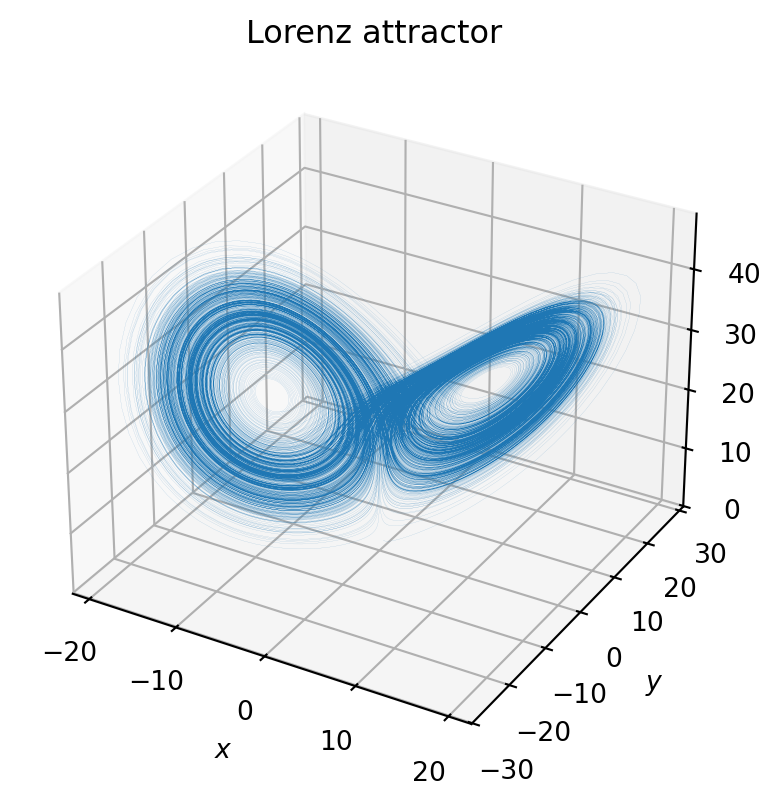

In [22]:
ax = plt.figure(dpi=192).add_subplot(projection="3d")

ax.plot(*x, lw=0.03)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()